In [10]:
# need to reload for new inferencing
import importlib

import model_loader
import decoder
import encoder
import diffusion
import clip
import ddpm
import pipeline

importlib.reload(model_loader)
importlib.reload(decoder)
importlib.reload(encoder)
importlib.reload(diffusion)
importlib.reload(clip)
importlib.reload(ddpm)
importlib.reload(pipeline)

<module 'pipeline' from '/Users/xinyaoyin/Yandex.Disk.localized/Projects/Diffusion/sd/pipeline.py'>

Using device mps


100%|██████████| 100/100 [00:42<00:00,  2.37it/s]


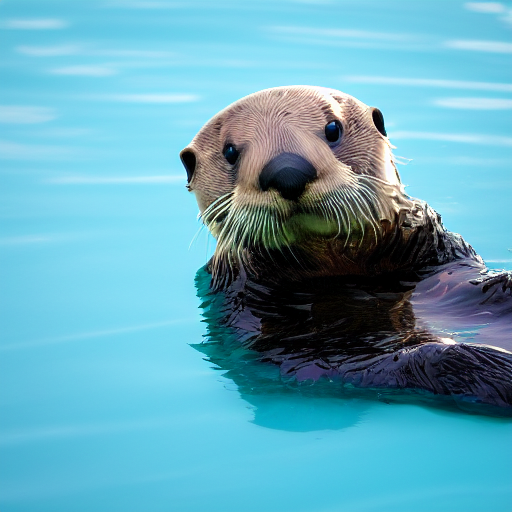

In [ ]:
import model_loader
import pipeline
from PIL import Image
from pathlib import Path
from transformers import CLIPTokenizer
import torch

DEVICE = "cpu"
ALLOW_MPS = False

if torch.backends.mps.is_available():
    DEVICE = "mps"
    
print(f"Using device {DEVICE}")

# load tokenizer
tokenizer = CLIPTokenizer("../data/vocab.json", merges_file = "../data/merges.txt")

model_file = "../data/v1-5-pruned-emaonly.ckpt"
models = model_loader.preload_models_from_standard_weights(model_file, DEVICE)

## Text to image

prompt = "A cute sea otter with big eyes in the sea, highly detailed, ultra sharp, cinematic, 8k resolution"
uncond_prompt = "" # negative prompt
do_cfg = True
cfg_scale = 7 # how much attention paid to the prompt (0 - 15)

## image to image

input_image = None
#image_path = "../images/dog.jpg"
#input_image = Image.open(image_path)

strength = 0.9
sampler = "ddpm"
num_inference_steps = 100 # more inference steps for better quality
seed = 42

output_image = pipeline.generate(
    prompt = prompt,
    uncond_prompt= uncond_prompt,
    input_image=input_image,
    strength=strength,
    do_cfg=do_cfg,
    cfg_scale=cfg_scale,
    sampler_name=sampler,
    n_inference_steps=num_inference_steps,
    seed=seed,
    models=models,
    device=DEVICE,
    idle_device="cpu",
    tokenizer=tokenizer
)
Image.fromarray(output_image)
